<h1 style="font-size: 40px; margin-bottom: 0px;">1.2 Python data visualization (II)</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 700px;"></hr>

In 1.1, we learned how to incorporate operating system functionalities into our workflow in order to analyze our class data and started learning how to visualize our data using our MTT data as an example. Today, we'll continue to learn basic data visualization while also reinforcing our skills in data processing using pandas DataFrames. We will use a slightly more complex dataset, specifically the CDC COVID-19 cases data, which contains not just quantitative values but also qualitative information as well. This will give us the opportunity to learn how to filter our data and generate line plots. Then we will use this plot as an example to fine tune formatting, styling, and exporting our plots.

We'll then finish by learning how to generate slightly more complex visualizations by layering multiple plots together to create publication-quality figures.

<strong>Learning objectives:</strong>
<ul>
    <li>Continue to practice working with DataFrames</li>
    <li>Learn how to filter a dataset</li>
    <li>Continue practicing plotting</li>
    <li>Learn how to fine tune visualizations</li>
    <li>Learn how to export plots</li>
</ul>

<h2>Import Packages</h2>

<ul>
    <li><code>numpy</code></li>
    <li><code>pandas</code></li>
    <li><code>matplotlib.pyplot</code></li>
    <li><code>matplotlib.dates</code> - to allow us to plot dates more easily</li>
    <li><code>seaborn</code> - to fine tune visualizations</li>
    <li><code>os</code></li>
</ul>

In [1]:
#Import the packages that we'll use today
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

<h1 style="font-size: 40px; margin-bottom: 0px;">More DataFrames practice</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 600px;"></hr>

To start today's lesson, let's import the data that we'll use for this part of today's lesson. We'll be importing the <code>cdc_covid_cases.csv</code> file <a href="https://data.cdc.gov/Case-Surveillance/Weekly-United-States-COVID-19-Cases-and-Deaths-by-/pwn4-m3yp/about_data" rel="noopener noreferrer"><u>available from the CDC</u></a>. The .csv file should have been pulled into your server along with today's notebook under the file path <code>~/MCB201B_F2026/Week_01/data/cdc_covid_cases.csv</code>.

Let's go ahead and import the dataset into this notebook.

In [2]:
#Load in our data in the usual way
covid_full = pd.read_csv(
    './data/cdc_covid_cases.csv'
)

Let's do a sanity check to see if it imported correctly. Note that this dataset is quite large with over 10,000 rows and 10 columns, so if you use the <code>.style</code> attribute, you will output the <u>entire</u> dataset as a stylized table. Recall from MCB201A that DataFrames have a <code>head</code> and <code>tail</code> attribute. 

So for this sanity check, let's just take a look at the first 5 rows as a stylized table.

In [3]:
#Quickly check to see how our data loaded in
covid_full.head().style

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
0,01/23/2020,AK,01/16/2020,01/22/2020,0,0,0,0,0,0
1,01/30/2020,AK,01/23/2020,01/29/2020,0,0,0,0,0,0
2,02/06/2020,AK,01/30/2020,02/05/2020,0,0,0,0,0,0
3,02/13/2020,AK,02/06/2020,02/12/2020,0,0,0,0,0,0
4,02/20/2020,AK,02/13/2020,02/19/2020,0,0,0,0,0,0


<h2 style="font-size: 32px;">Convert to dates to datetime data type</h2>

As you can see in the dataset that we've imported, we have qualitative information, quantitative case numbers, and dates as well. Let's take a look at the dates and how Python is understanding them.

In [4]:
#Here we're just pulling out a single element from our DataFrame
#so that we can take a look at the object type
#We're specifically interested in how the dates are being understood by our notebook
type(covid_full['date_updated'][4])
#You can see that our Python notebook is understanding it as a string
#so as just plain text without any inherent date or time values

str

What you can see is that Python is interpreting it as a string, so while we know that there's temporal information associated with all the values in each of the dates columns, Python does not. It is simply understanding it and interpreting it as a string of characters without any temporal information associated with it.

So what we can do is to tell Python that the values within the dates columns have temporal information in them by using the <code>pd.to_datetime()</code> function. <a href="https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html" rel="noopener noreferrer"><u>Documentation for <code>pd.to_datetime()</code> can be found here.</u></a>

In [5]:
#We can use the pd.to_datetime() function to then convert those strings to actual objects with date and time value
pd.to_datetime(covid_full['date_updated'])

0       2020-01-23
1       2020-01-30
2       2020-02-06
3       2020-02-13
4       2020-02-20
           ...    
10375   2023-04-13
10376   2023-04-20
10377   2023-04-27
10378   2023-05-04
10379   2023-05-11
Name: date_updated, Length: 10380, dtype: datetime64[ns]

In [6]:
#While the above method can update for a single column
#We need to update for more than one column
#So we can then set up a for-loop to check through each column and update only when needed
#Fortunately, all our columns that have dates in them have the pattern 'date'
#So we can then use that to tell Python which columns to convert to datetime objects
for col in covid_full.columns:
    if 'date' in col:
        covid_full[col] = pd.to_datetime(covid_full[col])
    else:
        pass

In [7]:
type(covid_full['end_date'][4])
#Can now see that the columns have been updated

pandas._libs.tslibs.timestamps.Timestamp

<h2 style="font-size: 32px;">Filtering DataFrames</h2>

Recall from the above example when we pulled the dates and from earlier lessons that we can make use of dictionary notation and slice notation to retrieve information from our DataFrame. Let's do a quick practice here.

In [8]:
#First practice pulling out a single column
covid_full['tot_cases']

0             0
1             0
2             0
3             0
4             0
          ...  
10375    186284
10376    186399
10377    186539
10378    186668
10379    187034
Name: tot_cases, Length: 10380, dtype: int64

In [9]:
#We can also pull out more than one column at a time
#In this case, we use a list of our column names
covid_full[['start_date', 'end_date', 'tot_cases']]

,start_date,end_date,tot_cases
0,2020-01-16,2020-01-22,0
1,2020-01-23,2020-01-29,0
2,2020-01-30,2020-02-05,0
3,2020-02-06,2020-02-12,0
4,2020-02-13,2020-02-19,0
...,...,...,...
10375,2023-04-06,2023-04-12,186284
10376,2023-04-13,2023-04-19,186399
10377,2023-04-20,2023-04-26,186539
10378,2023-04-27,2023-05-03,186668


In [10]:
#We can also pull out by index or row
covid_full.iloc[0:100]

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
0,2020-01-23,AK,2020-01-16,2020-01-22,0,0,0,0,0,0
1,2020-01-30,AK,2020-01-23,2020-01-29,0,0,0,0,0,0
2,2020-02-06,AK,2020-01-30,2020-02-05,0,0,0,0,0,0
3,2020-02-13,AK,2020-02-06,2020-02-12,0,0,0,0,0,0
4,2020-02-20,AK,2020-02-13,2020-02-19,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
95,2021-11-18,AK,2021-11-11,2021-11-17,142443,2919,838,11,0,0
96,2021-11-25,AK,2021-11-18,2021-11-24,144792,2349,866,28,0,0
97,2021-12-02,AK,2021-11-25,2021-12-01,146508,1716,877,11,0,0
98,2021-12-09,AK,2021-12-02,2021-12-08,148018,1510,882,5,0,0


While specifically calling up a known set of columns and rows can be helpful, you will probably find yourself in instances where you may not easily know the exact row or column that you want to retrieve, only what subset of data you're interested in. For example, since we're in California, let's say we're most interested in the cases relating to California.

First let's identify what column we'll need to use to filter our data.

In [11]:
#Now if we want just the rows associated with a specific state
covid_full['state']
#We first have to pull out the state column

0        AK
1        AK
2        AK
3        AK
4        AK
         ..
10375    WY
10376    WY
10377    WY
10378    WY
10379    WY
Name: state, Length: 10380, dtype: object

Then, how do we know which values relate to California? In other words, how do we set up a conditional statement to identify the California portion of the dataset?

In [12]:
#Then we can set up a conditional statement for the state that we want to pull
#Recall that the double equals sign sets up a conditional statement for whether or not the left matches the right
#So with our column, it'll check through each element of that column
#and then return True if that element matches or False if it does not
#and it'll do that for all elements in that column
covid_full['state'] == 'CA'
#Here we are checking which rows are then match the string 'CA'
#So any row where the state is 'CA' will return True
#While any row where that doesn't match will return False

0        False
1        False
2        False
3        False
4        False
         ...  
10375    False
10376    False
10377    False
10378    False
10379    False
Name: state, Length: 10380, dtype: bool

Now we have identified the portion of the dataset in the <code>'state'</code> column that relates to California's COVID data. We can now use this output combined with <code>.loc[]</code> to filter our dataset to just focus on California's cases.

We can also include <code>.copy()</code> to save a copy of the subsetted data to a new variable and prevent potential issues from arising when working with a temporary view of the subsetted DataFrame.

In [13]:
#We can then pull out all the data associated with those rows matching 'CA'
#aka the rows containing data for the state of California
#and we can save the resulting DataFrame to a new variable
covid_ca = covid_full.loc[covid_full['state'] == 'CA' , :].copy()

#Breaking it down into pieces
# covid_full['state'] == 'CA'
#this is saying we want to find all the rows in the 'state' column where the element is 'CA'
#
# covid_full.loc[covid_full['state'] == 'CA', :]
#this is saying once we found those rows, pull out all the columns (indicated by the colon in the 2nd dimension of .loc[ row , col ])
#and the data that we're pulling out is from the covid_full DataFrame (indicated by the covid_full preceding the .loc)

# .copy()
#this just indicates that we want to make a separate object for the resuting DataFrame
#rather than have it be a view of the original DataFrame

In [14]:
#We can then take a look at the resulting DataFrame
covid_ca

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
865,2020-01-23,CA,2020-01-16,2020-01-22,0,0,0,0,0,0
866,2020-01-30,CA,2020-01-23,2020-01-29,2,2,0,0,0,0
867,2020-02-06,CA,2020-01-30,2020-02-05,8,6,0,0,0,0
868,2020-02-13,CA,2020-02-06,2020-02-12,16,8,0,0,0,0
869,2020-02-20,CA,2020-02-13,2020-02-19,30,14,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
1033,2023-04-13,CA,2023-04-06,2023-04-12,12205573,11054,101434,124,0,0
1034,2023-04-20,CA,2023-04-13,2023-04-19,12218091,12518,101549,115,0,0
1035,2023-04-27,CA,2023-04-20,2023-04-26,12230624,12533,101663,114,0,0
1036,2023-05-04,CA,2023-04-27,2023-05-03,12242634,12010,101777,114,0,0


Now let's take a look at just the first five rows to see how the filtering went.

In [15]:
covid_ca.head()

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
865,2020-01-23,CA,2020-01-16,2020-01-22,0,0,0,0,0,0
866,2020-01-30,CA,2020-01-23,2020-01-29,2,2,0,0,0,0
867,2020-02-06,CA,2020-01-30,2020-02-05,8,6,0,0,0,0
868,2020-02-13,CA,2020-02-06,2020-02-12,16,8,0,0,0,0
869,2020-02-20,CA,2020-02-13,2020-02-19,30,14,0,0,0,0


What if we're particularly interested in the case numbers for California between June 1, 2021 and September 1, 2021? How could we use our filtered dataset to then look at this specific window of time?

In [16]:
#Likewise, if we want to filter our DataFrame based on some date
#We can set up a conditional statement for that
#Below is a conditional statement for us to set the lower bound
#So anything after June 1, 2021
covid_ca['start_date'] >= pd.to_datetime('06/01/2021')

865     False
866     False
867     False
868     False
869     False
        ...  
1033     True
1034     True
1035     True
1036     True
1037     True
Name: start_date, Length: 173, dtype: bool

In [17]:
#And here is the conditional statement to set the upper bound
#So anything before Sept 1, 2021
covid_ca['start_date'] <= pd.to_datetime('09/01/2021')

865      True
866      True
867      True
868      True
869      True
        ...  
1033    False
1034    False
1035    False
1036    False
1037    False
Name: start_date, Length: 173, dtype: bool

In [18]:
#And then we can combine that together to find the intersection of both
#In other words between June 1, 2021 and Sept 1, 2021
(covid_ca['start_date'] >= pd.to_datetime('06/01/2021')) & (covid_ca['start_date'] <= pd.to_datetime('09/01/2021'))

865     False
866     False
867     False
868     False
869     False
        ...  
1033    False
1034    False
1035    False
1036    False
1037    False
Name: start_date, Length: 173, dtype: bool

In [19]:
#Like we did to pull out the California data
#We can apply that conditional to pull out just the data for the date range 6/1/2021 to 9/1/2021
covid_ca.loc[(covid_ca['start_date'] >= pd.to_datetime('06/01/2021')) & 
    (covid_ca['start_date'] <= pd.to_datetime('09/01/2021')), :]

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
937,2021-06-10,CA,2021-06-03,2021-06-09,3853677,6655,62039,309,0,0
938,2021-06-17,CA,2021-06-10,2021-06-16,3859768,6091,62169,130,0,0
939,2021-06-24,CA,2021-06-17,2021-06-23,3866342,6574,62384,215,0,0
940,2021-07-01,CA,2021-06-24,2021-06-30,3875227,8885,62685,301,0,0
941,2021-07-08,CA,2021-07-01,2021-07-07,3886793,11566,62917,232,0,0
942,2021-07-15,CA,2021-07-08,2021-07-14,3908447,21654,63168,251,0,0
943,2021-07-22,CA,2021-07-15,2021-07-21,3944648,36201,63339,171,0,0
944,2021-07-29,CA,2021-07-22,2021-07-28,3998313,53665,63516,177,0,0
945,2021-08-05,CA,2021-07-29,2021-08-04,4070342,72029,63729,213,0,0
946,2021-08-12,CA,2021-08-05,2021-08-11,4156032,85690,63975,246,0,0


<h1 style="font-size: 40px; margin-bottom: 0px;">More plotting practice</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 600px;"></hr>

In 1-1, we used our class MTT data to generate a simple bar plot comparing the relative absorbance between our control and edited cells. Today, we'll continue to practice more plotting using our filtered CDC dataset to plot the number of new cases over the full period of time covered by this dataset.

So we'll use the <code>plt.plot()</code> function to output a line plot of case numbers. <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html" rel="noopener noreferrer"><u>Documentation for <code>plt.plot()</code> can be found here.</u></a>

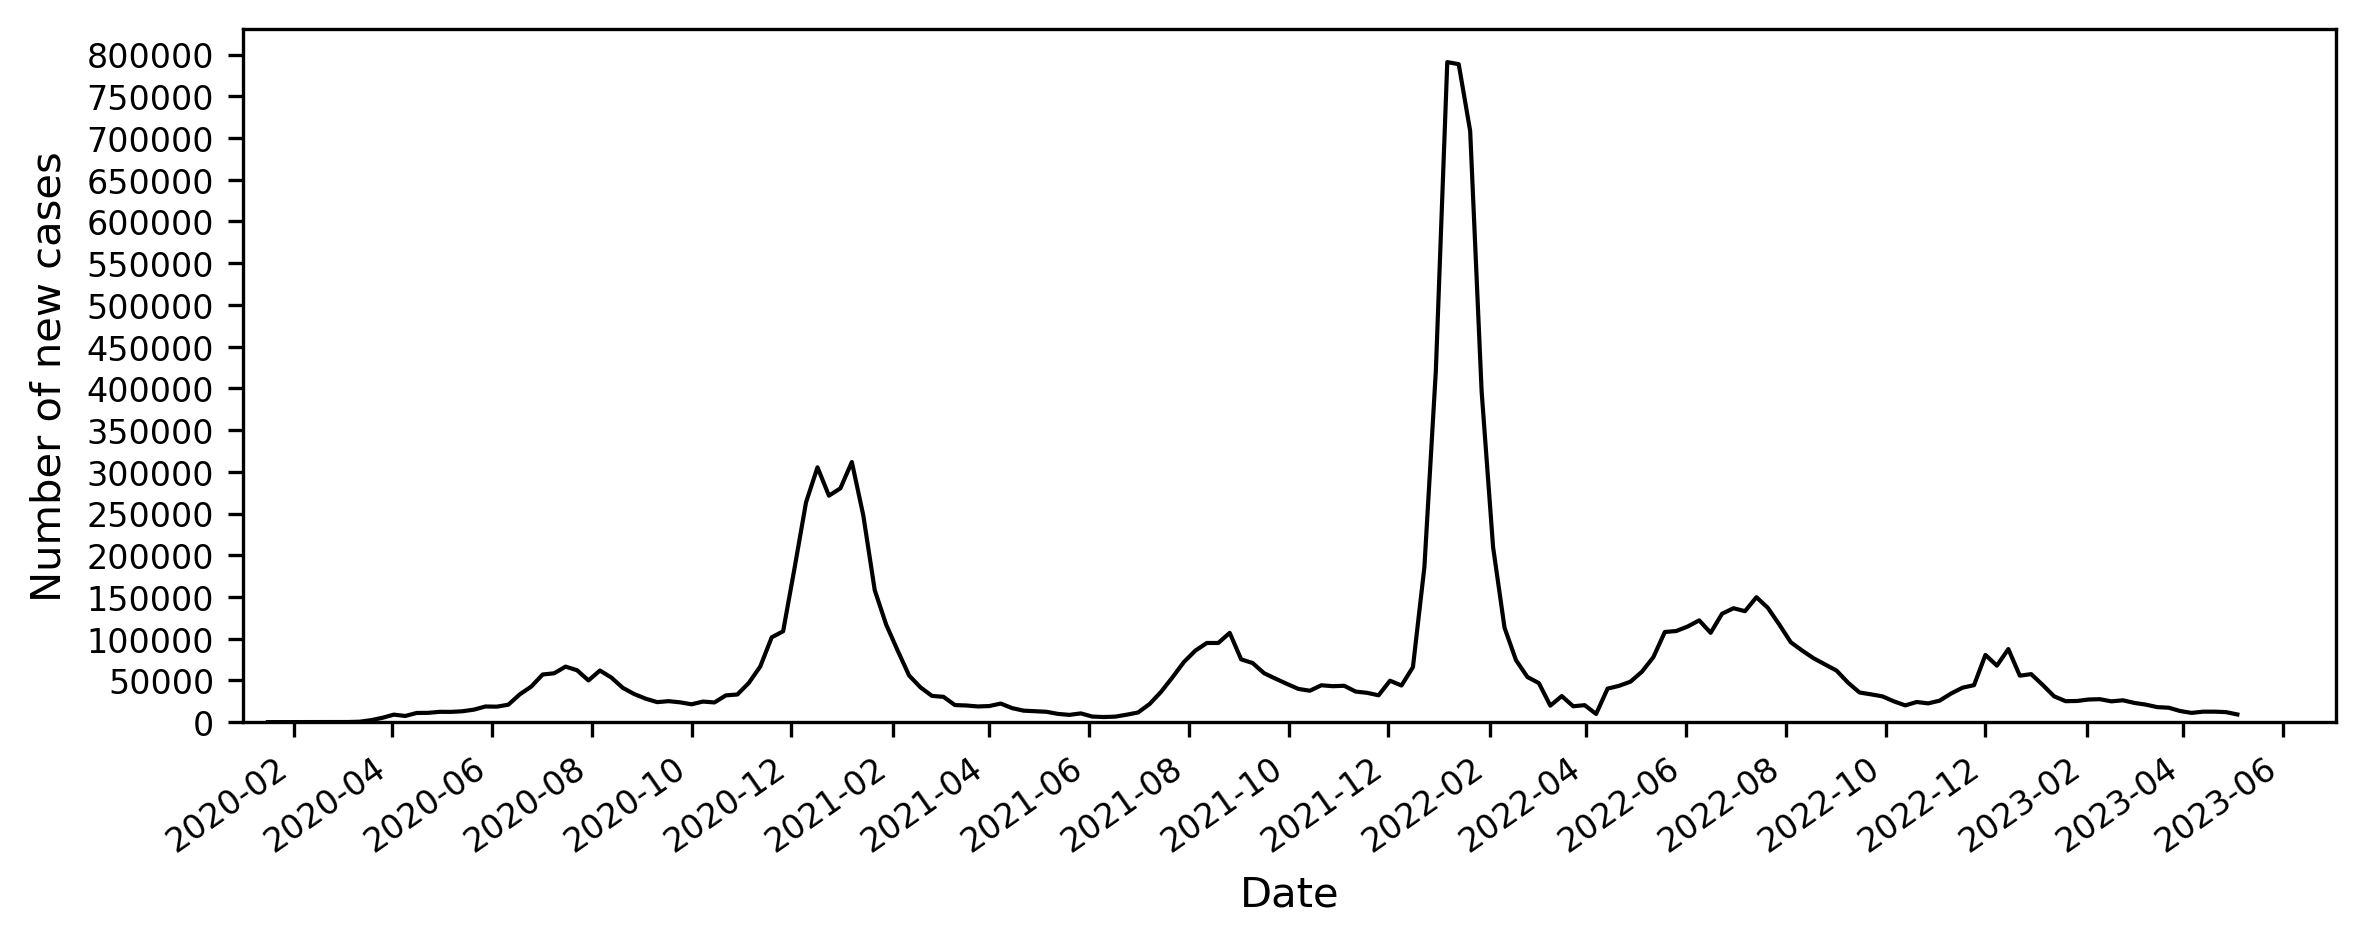

In [20]:
#Set up our usual figure the way we usually do
fig, ax = plt.subplots()

#Plot our line plot
plt.plot(
    covid_ca['start_date'],     #Plot the dates along the x-axis. Here we just use the start date column
    covid_ca['new_cases'],      #Plot the new cases on the y-axis
    color='k',                  #set the color of the line as black
    lw=1,                       #set the linewidth as 1
)

#We can then make a bunch of different adjustments to our plot

#Update x-axis title
ax.set_xlabel(
    'Date',
)

#Update y-axis title
ax.set_ylabel(
    'Number of new cases',
)


#Update how our x-tick labels will be
plt.xticks(
    rotation=35,
    ha='right',
    size=8,
)

#Update our x-axis limit
#Specifically, we set our lower limit to be 1/1/2020
#This sets 1/1/2020 as the left-most part of our plot
ax.set_xlim(
    pd.to_datetime(
        '01/01/2020',
    )
)

#Do the same for the y-axis limit
#We set the lowest part of our plot to be 0
ax.set_ylim(
    0,
)

#Update our y-axis ticks
#Specifically set how many ticks and their labels
plt.yticks(
    np.arange(0, 850000, 50000),      #This sets the tick positions. We feed it an array from 0 to 850,000 with step size of 50,000.
                                      #So the lowest tick will be 0, and the upper-most tick will be 800,000
                                      #And there will be a tick every 50,000
    np.arange(0, 850000, 50000),      #This sets the labels up using the same array. So the labels match the ticks.
    size=8,                           #This updates the font size for the labels
)

#Update our x-axis ticks
#This is slightly more complicated since we're working with dates
#So we pull out the x-axis major tick marks and set them to be every 2 months
ax.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=2,
    ),
)

#Then we can update the dimensions of our figure
fig.set_size_inches(9,3)

#And we can update the resolution
fig.set_dpi(300)

plt.show()

<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #1: Filter for California's, Florida's and New York's data</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 950px;"></hr>

For this exercise, see if you can set up a for-loop that will allow you to filter the original full COVID dataset to obtain separate DataFrames for California's, Florida's and New York's data and have each DataFrame be an element in a list.

In [21]:
#We can first set up a list containing the states that we want to pull out
states = ['CA', 'FL', 'NY']

#Then we can initialize an empty list
state_data = []

#Then we set up our for-loop to go through our list of states
for state in states:
    #It'll first pull out the data associated with that state and assign it to a variable
    covid_filtered = covid_full.loc[covid_full['state'] == state , :].copy()
    #Then it will append that DataFrame to our state_data list
    state_data.append(covid_filtered)
    #And it'll repeat for each state in our list

In [22]:
#We can then pull out individual DataFrames to take a look to see if it filtered correctly
state_data[2].head().style

,date_updated,state,start_date,end_date,tot_cases,new_cases,tot_deaths,new_deaths,new_historic_cases,new_historic_deaths
6574,2020-01-23 00:00:00,NY,2020-01-16 00:00:00,2020-01-22 00:00:00,0,0,0,0,0,0
6575,2020-01-30 00:00:00,NY,2020-01-23 00:00:00,2020-01-29 00:00:00,0,0,0,0,0,0
6576,2020-02-06 00:00:00,NY,2020-01-30 00:00:00,2020-02-05 00:00:00,0,0,0,0,0,0
6577,2020-02-13 00:00:00,NY,2020-02-06 00:00:00,2020-02-12 00:00:00,0,0,0,0,0,0
6578,2020-02-20 00:00:00,NY,2020-02-13 00:00:00,2020-02-19 00:00:00,0,0,0,0,0,0


<h1 style="font-size: 40px; margin-bottom: 0px;">Exercise #2: Plot new deaths for CA, NY, and FL</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 950px;"></hr>

For this exercise, plot the number of new deaths for CA, NY, and FL all on the same plot. To do this, you'll use <code>plt.subplots()</code> to set up your plots the way we've been doing so far. Now, instead of a single <code>plt.plot()</code> you can have multiple <code>plt.plot()</code> blocks of code one after the other, and they'll be plotted onto the same plot.

In [23]:
#We can set up a list of colors for each state
colors = ['black', 'blue', 'orange']

#Then we can go through both our list of state data and our list of colors
for i, j in zip(state_data, colors):
    #Can see with zip(), we pair up the state with its color based on the positions they have in their lists
    print(i.loc[:,'state'], j)

865     CA
866     CA
867     CA
868     CA
869     CA
        ..
1033    CA
1034    CA
1035    CA
1036    CA
1037    CA
Name: state, Length: 173, dtype: object black
1730    FL
1731    FL
1732    FL
1733    FL
1734    FL
        ..
1898    FL
1899    FL
1900    FL
1901    FL
1902    FL
Name: state, Length: 173, dtype: object blue
6574    NY
6575    NY
6576    NY
6577    NY
6578    NY
        ..
6742    NY
6743    NY
6744    NY
6745    NY
6746    NY
Name: state, Length: 173, dtype: object orange


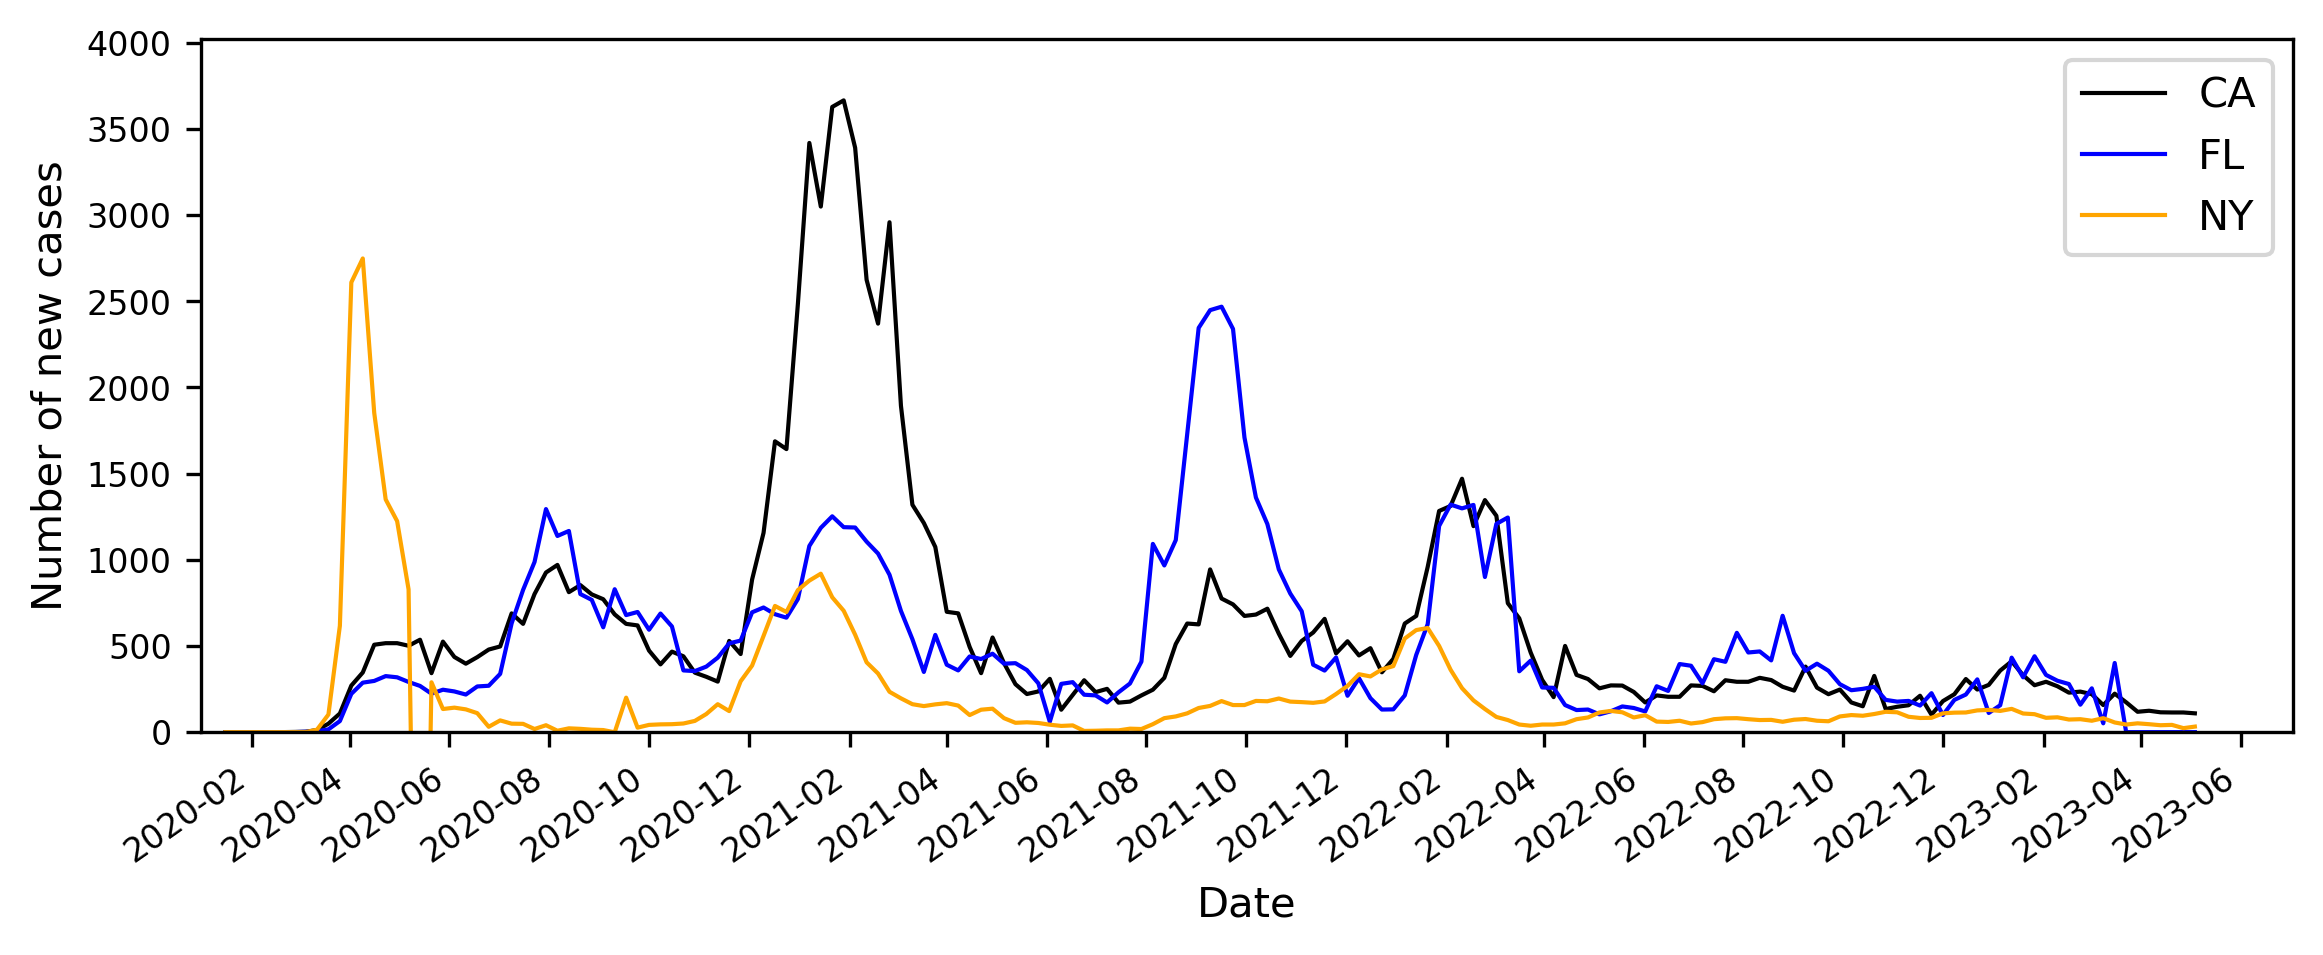

In [24]:
#Set up our usual figure the way we usually do
fig, ax = plt.subplots()

#Lists to iterate through
#This one sets color of the line plot
colors = ['black', 'blue', 'orange']
#This one sets the label for our legend
labels = ['CA', 'FL', 'NY']

#Set up our for-loop to iterate through three lists simultaneously
for i, j, k in zip(state_data, colors, labels):
    #Then we plot our data for each state
    #As the for-loop repeats, the next state's lines will be plotted over the previous one on the same axes
    plt.plot(
        i['start_date'],      #Plot dates along x-axis
        i['new_deaths'],      #Plot new deaths along y-axis
        color=j,              #Set the color, which will update for each iteration of the for-loop
        lw=1,                 #Set linewidth to be a constant 1
        label=k,              #Set the label, which will update for each iteration of the for-loop
    )

#Plot the legend, so we can see what line is for what state
plt.legend()

#Set x-axis title
ax.set_xlabel(
    'Date',
)

#Set y-axis title
ax.set_ylabel(
    'Number of new cases',
)

#Set xtick labels properties
plt.xticks(
    rotation=35,
    ha='right',
    size=8,
)

#Set the x-limit lower bound
ax.set_xlim(
    pd.to_datetime(
        '01/01/2020',
    )
)

#Set the y-limit lower bound
ax.set_ylim(
    0,
)

#Set the y-tick marks
plt.yticks(
    np.arange(0, 4500, 500),
    np.arange(0, 4500, 500),
    size=8,
)

#Set the x-tick marks
ax.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=2,
    ),
)

#Set the figure dimensions
fig.set_size_inches(9,3)

#Set the figure resolution
fig.set_dpi(300)

plt.show()

We can take a quick break here, and then when we reconvene, we'll go over the first two exercises, and proceed with the rest of today's notebook.

<h1 style="font-size: 40px; margin-bottom: 0px;">Exporting your plots</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 550px;"></hr>

Now that you have a nice plot, you can export it as a PDF using <code>fig.savefig()</code>. <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.savefig.html#matplotlib.figure.Figure.savefig" rel="noopener noreferrer"><u>Documentation for <code>fig.savefig()</code> can be found here.</u></a>

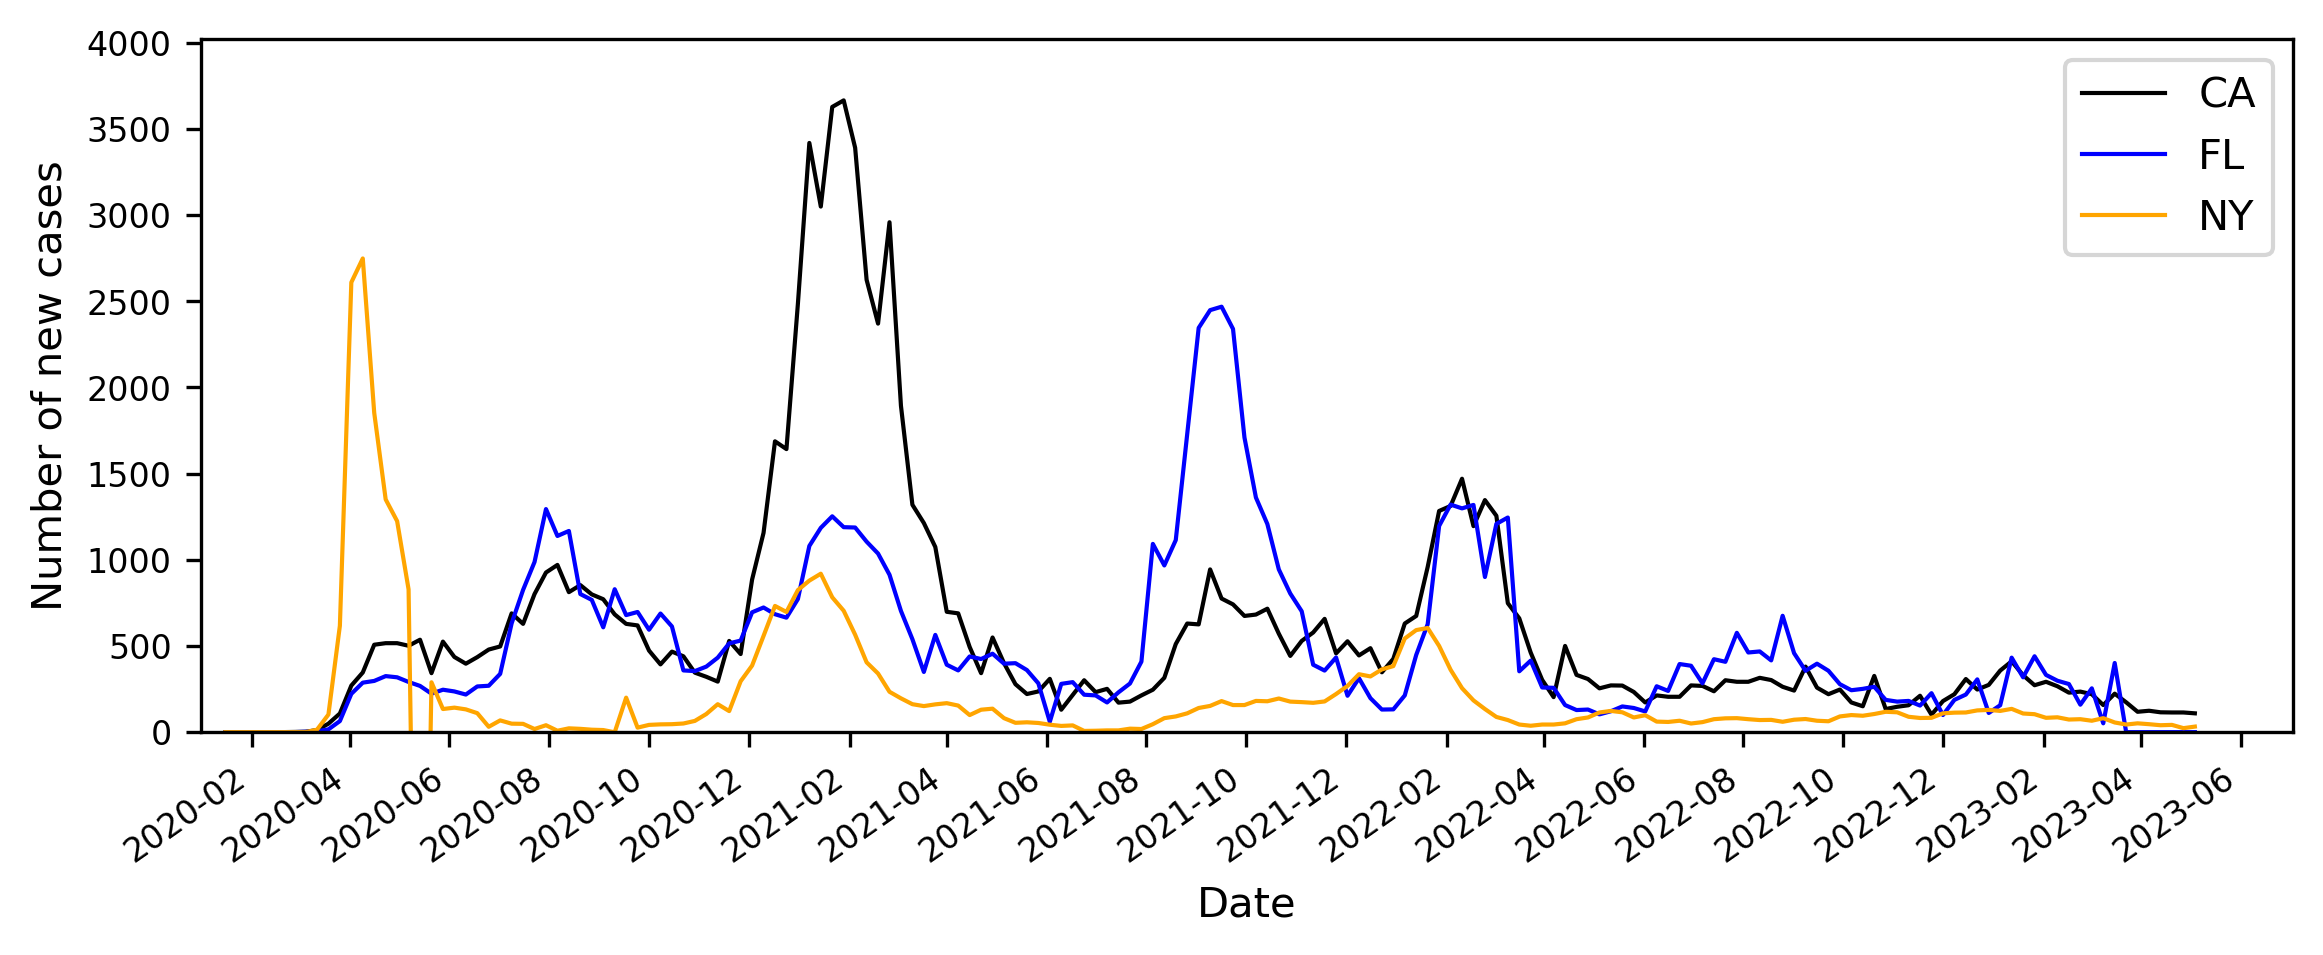

In [25]:
#Set up our usual figure the way we usually do
fig, ax = plt.subplots()

#Lists to iterate through
#This one sets color of the line plot
colors = ['black', 'blue', 'orange']
#This one sets the label for our legend
labels = ['CA', 'FL', 'NY']

#Set up our for-loop to iterate through three lists simultaneously
for i, j, k in zip(state_data, colors, labels):
    #Then we plot our data for each state
    #As the for-loop repeats, the next state's lines will be plotted over the previous one on the same axes
    plt.plot(
        i['start_date'],      #Plot dates along x-axis
        i['new_deaths'],      #Plot new deaths along y-axis
        color=j,              #Set the color, which will update for each iteration of the for-loop
        lw=1,                 #Set linewidth to be a constant 1
        label=k,              #Set the label, which will update for each iteration of the for-loop
    )

#Plot the legend, so we can see what line is for what state
plt.legend()

#Set x-axis title
ax.set_xlabel(
    'Date',
)

#Set y-axis title
ax.set_ylabel(
    'Number of new cases',
)

#Set xtick labels properties
plt.xticks(
    rotation=35,
    ha='right',
    size=8,
)

#Set the x-limit lower bound
ax.set_xlim(
    pd.to_datetime(
        '01/01/2020',
    )
)

#Set the y-limit lower bound
ax.set_ylim(
    0,
)

#Set the y-tick marks
plt.yticks(
    np.arange(0, 4500, 500),
    np.arange(0, 4500, 500),
    size=8,
)

#Set the x-tick marks
ax.xaxis.set_major_locator(
    mdates.MonthLocator(
        interval=2,
    ),
)

#Set the figure dimensions
fig.set_size_inches(9,3)

#Set the figure resolution
fig.set_dpi(300)

plt.show()

#We can make directories using the os module's makedirs() function
os.makedirs(
    './figures',     #Set our directory name
    exist_ok=True,   #This makes it such that if the folder already exists, Python will just ignore the error
)

#Save our figure
fig.savefig('./figures/covid_cases_ny_ca_fl.pdf', bbox_inches='tight')
#By setting bbox_inches to 'tight', we prevent any unintended cropping of our plot

You should see now that in the <code>figure</code> subdirectory, your line plot exported as a PDF file. Later in 4-2 Making publication quality figures, you'll learn how to make publication quality figures, and why it's helpful to export all your plots as a PDF. 

<h1 style="font-size: 40px; margin-bottom: 0px;">Swarmplots with error bars</h1>

<hr style="margin-left: 0px; border: 0.25px solid; border-color: #000000; width: 550px;"></hr>

A common way of displaying data with multiple biological replicates is a swarm plot with each dot representing individual replicates, and then adding error bars on top of the swarmplot. For this part of today's notebook, we'll make use of <code>seaborn</code>, which is built on the <code>matplotlib</code> package.

Let's make use of 1-1's code and import our processed class MTT data in this notebook.

In [26]:
#Load in our mtt data from 1-1
mtt_data = pd.read_csv('./data/class_mtt_yap_data.csv')

As usual, let's do a quick sanity check to see how the data imported.

In [27]:
#Just a quick check to see if it imported correctly
mtt_data

,control,yapko
0,1.245023,2.016001
1,0.818574,0.398504
2,1.255742,1.026822
3,0.597438,0.498545
4,1.083223,0.725551


Now let's learn how to plot a swarmplot using <code>seaborn</code>. We'll learn how to do this piece by piece, breaking down the individual steps to set up a slightly more complex plot.

<h2>Set up our figure for fine tuning</h2>

Like with our COVID plots, we will set up our figure in the usual method, so we can fine tune the formatting and style as well as layer multiple plots on top of one another.

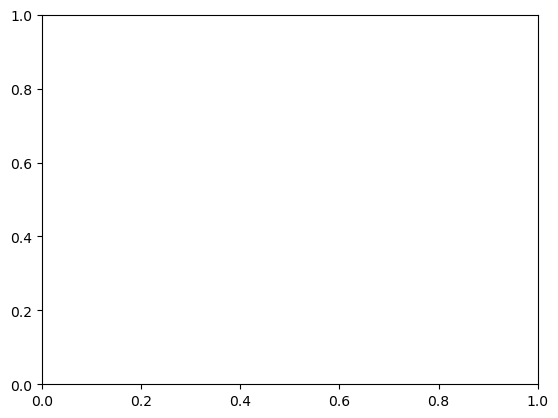

In [28]:
#For this example, we'll go step by step
#This part just sets up the plotting area
fig, ax = plt.subplots()

Running that alone, you should just see an empty plot.

<h2>Prepare a color palette</h2>

As with our line plot, we can adjust the coloring, and here, we'll set up a color palette using hexcode to pick specific colors.

In [29]:
#This sets what colors we want to use
#We can either specify by color name
#Or we can use hexcodes to specify specific colors as well
dot_colors = ['#777777', '#E64B35']

<h2>Plot a swarmplot</h2>

Matplotlib's ability to create a swarmplot is a bit more limited, so we can make use of <code>seaborn</code>, which has a function for us to create a swarmplot. Swarmplots are helpful when you want to show each individual data point, so that the reader has an idea of how the distribution of your data looks by looking directly at the raw data points.

The function that we'll use is the <code>sns.swarmplot()</code> function. <u><a href="https://seaborn.pydata.org/generated/seaborn.swarmplot.html" rel="noopener noreferrer" target="_blank">Documentation for <code>sns.swarmplot()</code> can be found here.</a></u>

We'll pass our DataFrame to the function to see how it looks like without additional modifications.

<Axes: >

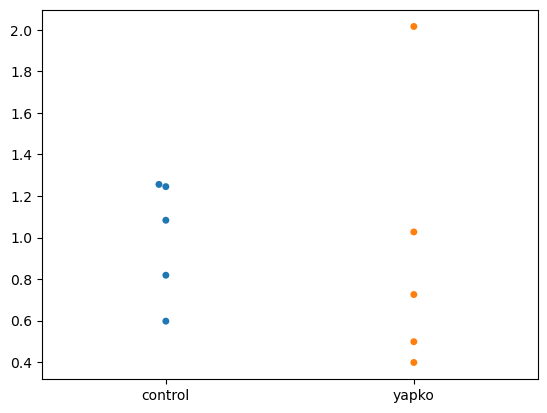

In [30]:
#We can then plot a very basic swarm plot
#First just pass our mtt_data DataFrame to the swarmplot function
sns.swarmplot(
    data=mtt_data,
)

#you should then see a very barebones swarmplot
#each dot represents an individual datapoint

We can make minor adjustments by passing additional arguments to the function, such as:
<ul>
    <li><code>s</code> - the size of our markers</li>
    <li><code>palette</code> - color palette for our markers</li>
</ul>

<Axes: >

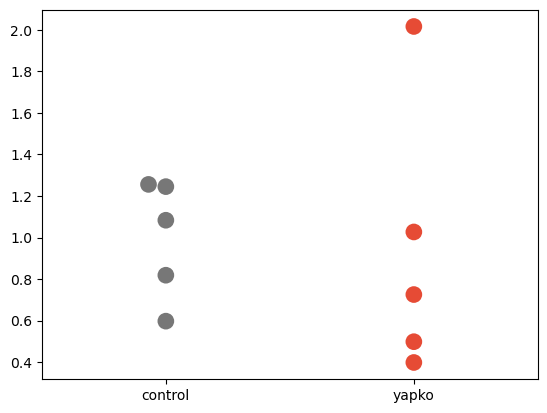

In [31]:
#Then we can update how the swarmplot looks by passing additional arguments to the function
sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
)

You can see that we have the basic swarm plot, but like with our other plots, there's still a few things missing, such as properly formatted labels for our groups on the X-axis, a Y-axis label, and proper Y-axis limits. Usually, swarmplots also include descriptive statistics that summarize the raw data that is shown, and this can include the mean and error bars denoting the standard deviation or standard error.

Before we start adjusting the axes, let's add in our descriptive statistics overlaid on top of our raw data points.

<h2>Overlay descriptive statistics</h2>

One thing we can do is to overlay plots on top of one another to convey additional information within a single plot without having to create subplots for each thing. This type of approach is helpful when we want to overlay descriptive statistics over our raw data points, so that the reader can see both the raw data as well as the statistics.

Descriptive statistics, such as the mean, can be plotted a few ways, such as a bar graph with error bars or as box-and-whisker plots. Both of these plots contain something that will be helpful to overlay onto our swarmplot. For the bar graph, it contains error bars, and for the box-and-whisker plot, it contains the ability to plot just the mean.

So what we can do is to take the portions of these plots that we like, strip away what we don't want to see, and overlay it onto our swarmplot.

Let's take a look at how these two plots will look like when plotted as a basic function.

<h3>Plot a bar graph to overlay</h3>

We can make use of the <code>sns.barplot()</code> function and pass our MTT data to the function to generate a bar plot kind of like what we did using <code>matplotlib.pyplot</code>. <a href="https://seaborn.pydata.org/generated/seaborn.barplot.html" rel="noopener noreferrer"><u>Documentation for <code>sns.barplot()</code> can be found here.</u></a>

<Axes: >

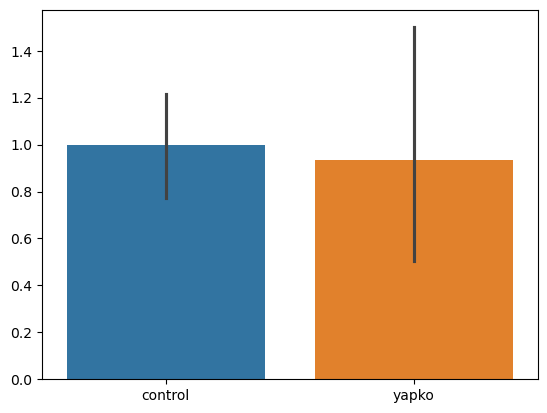

In [32]:
#We can then plot a bar plot
#What we'll need from this is just the error bars
#So we'll plot it and then modify it until we just have error bars left

#This plots a barebones bar plot
sns.barplot(
    data=mtt_data,
)

You should see a pretty basic bar graph with error bars already plotted. It has what we need, but now we need to strip out the parts that we don't by passing additional arguments through it.

Specifically, we want just the error bars, so we can make use of the following parameters:
<ul>
    <li><code>data</code> - we pass our DataFrame to this parameter so it can perform the calculations needed to plot the error bars</li>
    <li><code>estimator</code> - we want it to plot the mean since we want our error bars to be centered around the mean of our data. We can pass the <code>np.mean</code> function to this parameter</li>
    <li><code>alpha</code> - the parameter controlling the opacity of the boxplot bars. By changing this to <code>0</code>, we basically hide the bars depicting the mean, leaving only the error bars visisble</li>
    <li><code>errorbar</code> - by changing this parameter, we can tell Python if we want our error bars to denote standard deviation or standard error</li>
    <li><code>capsize</code> - the horizontal length of our error bars. This also tells Python that we want a horizontal cap (compare to previously, where there was no cap)</li>
    <li><code>err_kws</code> - we can pass a dictionary containing key:value pairs to this parameter to further fine tune our plot by mapping the key:value pairs we provide to specific parameters that exist for <code>plt.boxplot()</code>. <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html#matplotlib.axes.Axes.boxplot" rel="noopener noreferrer" target="_blank"><u>Documentation is here.</u></a></li>
</ul>

So let's work through each parameter one at a time to see how each change alters our bar plot.

<h3>Define the estimator</h3>

<Axes: >

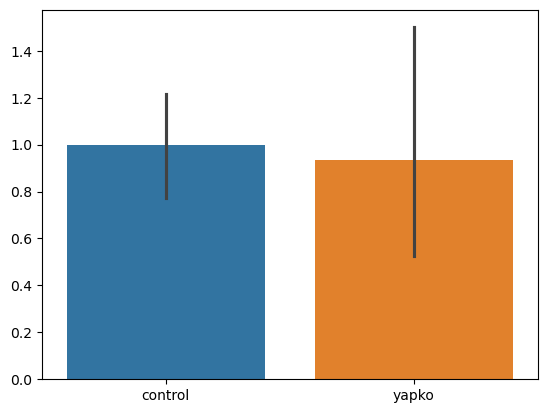

In [33]:
#Then we set the estimator to be the mean
sns.barplot(
    data=mtt_data,
    estimator=np.mean,
)

You can see nothing is changed because <code>seaborn.barplot()</code> will plot the mean by default.

<h3>Change the plot opacity to hide the bars (so we only see error bars)</h3>

<Axes: >

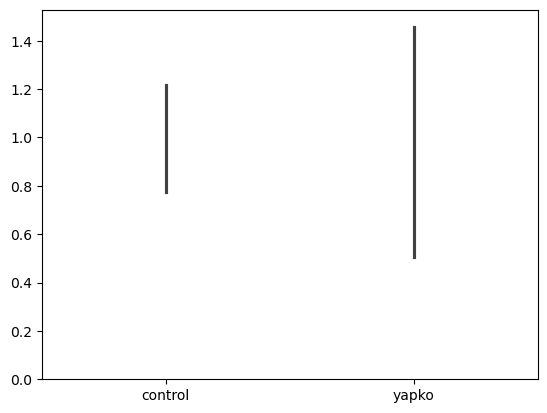

In [34]:
#Then we hide our bars
sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
)

The only things showing now are the error bars, and the error bars need further refining so that we have them denote either the standard deviation or the standard error.

<h3>Update what the error bars denote</h3>

<Axes: >

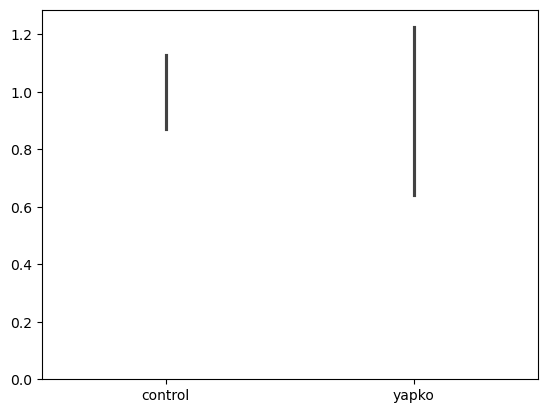

In [35]:
#Then we update error bars to denote standard error (of the mean)
sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
)

<h3>Add caps to error bars</h3>

<Axes: >

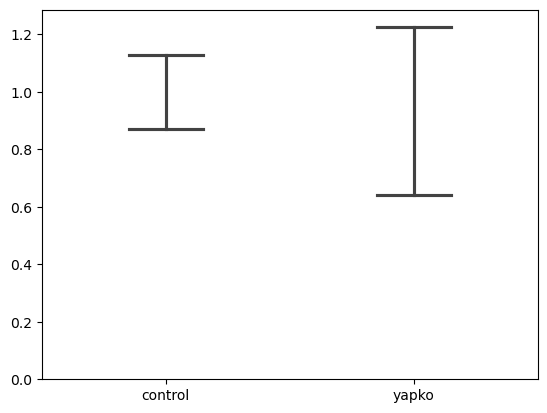

In [36]:
#And then we update how our error bars look
sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
)

<h3>Further refine error bars</h3>

<Axes: >

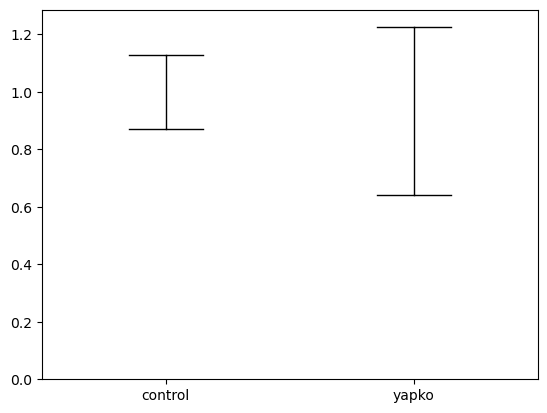

In [37]:
#And then refine that further by passing more arguments to the same function
sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
)

#you should then be able to see now that you are just left with error bars that more or less look how we're used to seeing them

So now our error bars look good, and let's use the box-and-whisker plot to get a horizontal line denoting the means of our data.

<h3>Plot a box-and-whisker plot to overlay</h3>

We'll similarly decompose a box-and-whisker plot to get it to just show a horizontal line for our means.

We can use the <code>sns.boxplot()</code> function and pass our same DataFrame to it to generate a box-and-whisker plot.

<a href="https://seaborn.pydata.org/generated/seaborn.boxplot.html" rel="noopener noreferrer" target="_blank"><u>Documentation for <code>sns.boxplot()</code> can be found here.</u></a>

<Axes: >

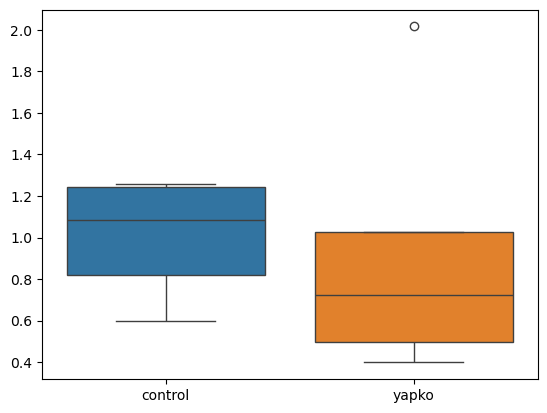

In [38]:
#We'll do the same thing with the box and whisker plot
#Here we only need it for its mean line

#So here it's just a barebones plot
sns.boxplot(
    data=mtt_data,
)

Here, you should see a basic box-and-whisker plot. We're going to make adjustments to the plot so that it shows just the mean, so we can use it as an overlay on top of our swarmplot.

Like with our bar plot, we can make use of the following parameters to just get what we need the plot to depict:
<ul>
    <li><code>data</code> - we pass our DataFrame to this parameter so it can perform the calculations needed to plot the error bars</li>
    <li><code>showmeans</code> - we want it to plot the mean</li>
    <li><code>meanline</code> - we want it to plot a horizontal line for the mean that spans the width of the box of our box-and-whisker plot</li>
    <li><code>width</code> - defines the width of our box and therefore also defines the horizontal span of our mean line</li>
    <li><code>meanprops</code> - we can pass a dictionary containing key:value pairs to this parameter to refine how we want the mean line to look. Like with <code>err_kws</code> for the bar plot, the key:value pairs will be passed to <code>plt.boxplot()</code>. <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.boxplot.html#matplotlib.axes.Axes.boxplot" rel="noopener noreferrer" target="_blank"><u>Documentation is here.</u></a></li>
    <li><code>medianprops</code> - we can pass a dictionary containing key:value pairs to this parameter to remove the median line of our box-and-whisker plot. Works like the <code>meanprops</code> parameter</li>
    <li><code>whiskerprops</code> - we can pass a dictionary containing key:value pairs to this parameter to remove the whiskers of our box-and-whisker plot. Also works like the <code>meanprops</code> parameter</li>
    <li><code>showfliers</code> - we can indicate with a Boolean, whether or not we want to hide outliers (fliers)</li>
    <li><code>showbox</code> - we can indicate with a Boolean, whether or not we want to hide the box of our box-and-whisker plot</li>
    <li><code>showcaps</code> - we can indicate with a Boolean, whether or not we want to the caps</li>
</ul>

Now if we go through each argument and see how the resulting box-and-whisker plot is altered with each parameter:

<h3>Show the mean</h3>

<Axes: >

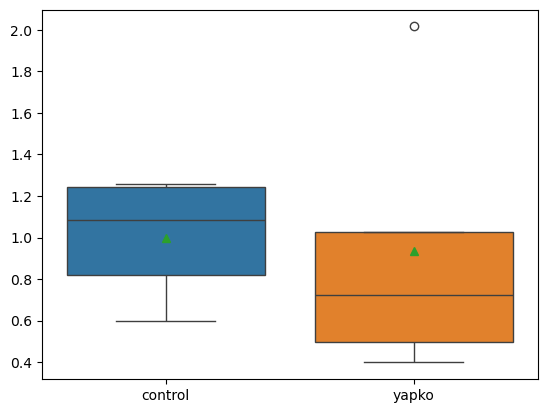

In [39]:
#Have it show the mean
sns.boxplot(
    data=mtt_data,
    showmeans=True,
)

It might be hard to see, but you can see a green triangle representing the mean value for each of our two groups. However, we want our mean to be a horizontal line, so we adjust this with the next parameter.

<h3>Create a horizontal line</h3>

<Axes: >

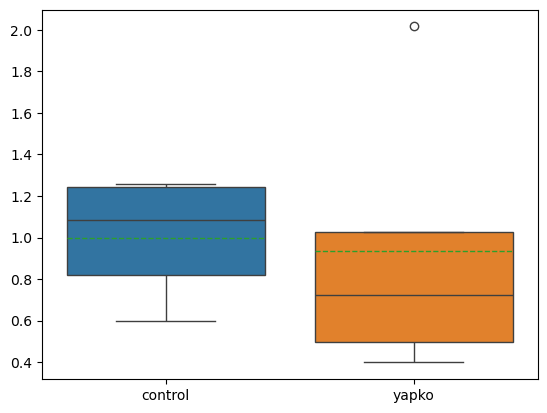

In [40]:
#Have it show the mean as a line
sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
)

This is probably still hard to see, but there is now a green dashed line that denotes where our mean values are. It spans the full width of the box, but we can shorten the length of the line by reducing the width of our boxes.

<h3>Shorten the length of the mean line</h3>

<Axes: >

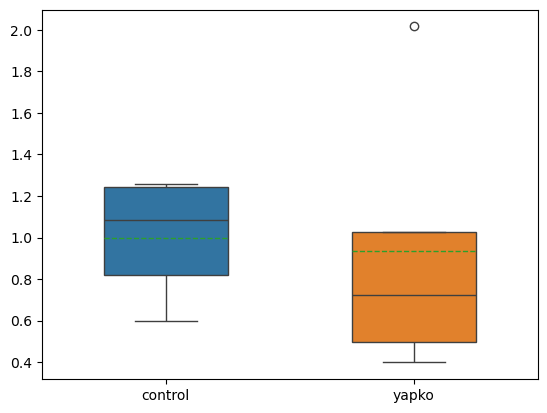

In [41]:
#Then we adjust the width of the box, which also then adjusts the width of the mean line as well
sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
)

<h3>Refine the mean line</h3>

<Axes: >

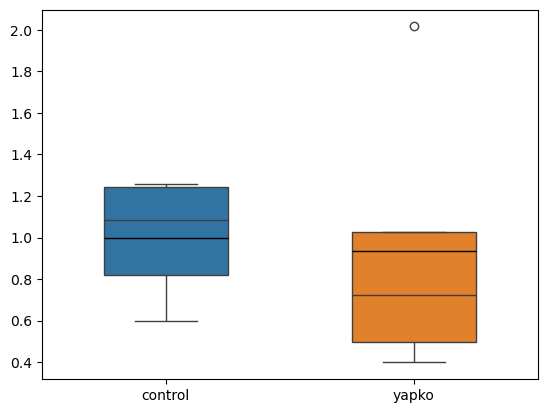

In [42]:
#Update how the mean line is drawn
sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
)

#So now we have the mean line how we want it, so now we remove everything else

Now the mean line is more clearly depicted, but there are still other parts of the box-and-whisker plot that we don't want.

<h3>Remove the median line</h3>

<Axes: >

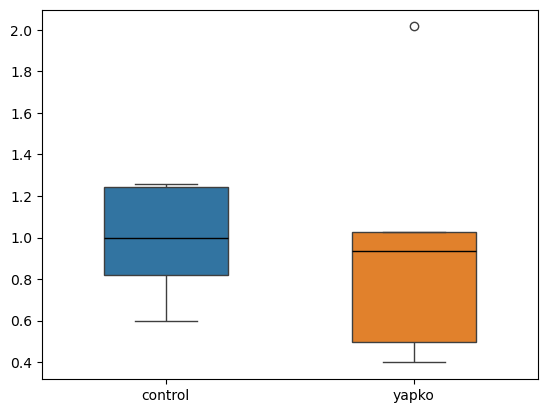

In [43]:
#We then begin removing all the other things we don't want to see
sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
)

Now that we've removed the median line, we can clearly see the mean line since that's the remaining black line in the box.

<h3>Remove whiskers</h3>

<Axes: >

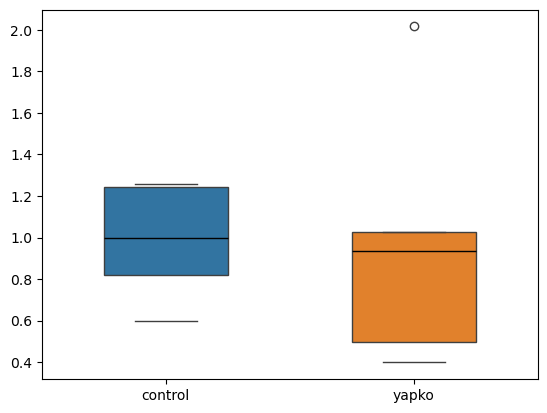

In [44]:
sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
)

<h3>Remove outliers (fliers)</h3>

A small thing to note is that in this step, we're not removing outliers from our dataset, we're only hiding them in the box-and-whisker plot since we don't need them for our visualization.

<Axes: >

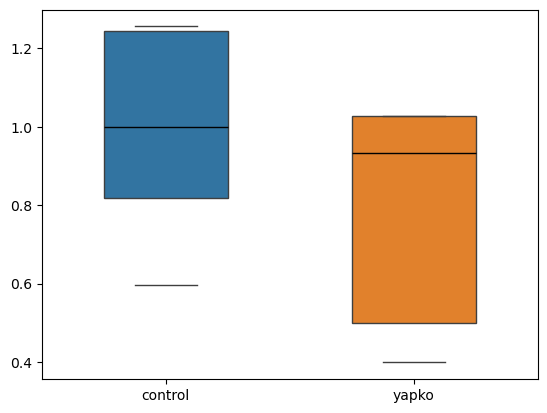

In [45]:
sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
)

You can see at least for this dataset that nothing has changed. This is because we don't have any notable outliers in our dataset.

<h3>Remove the box</h3>

<Axes: >

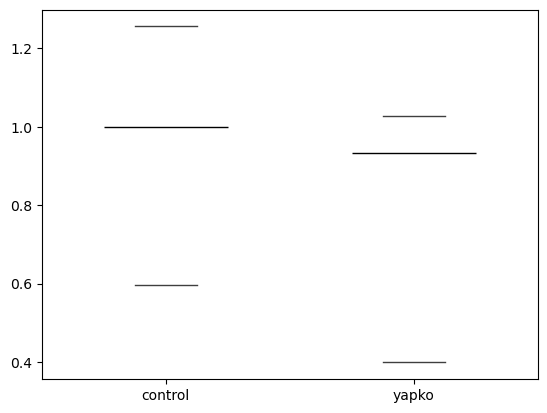

In [46]:
sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
)

<h3>Remove the caps</h3>

<Axes: >

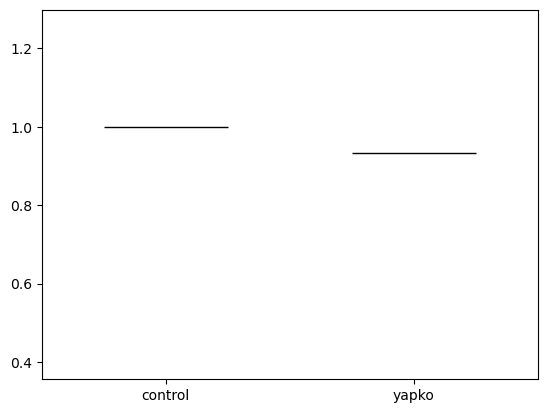

In [47]:
sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
)

<h3>Look at all three of our plots side by side</h3>

Let's now take a look at all three of our plots side by side by plotting them as subplots on a single figure. We can do this by making use of <code>plt.subplots()</code> and specifying how many subplots we want to be plotted. This way, instead of a single plot, we can have multiple plots generated side by side.

<Axes: >

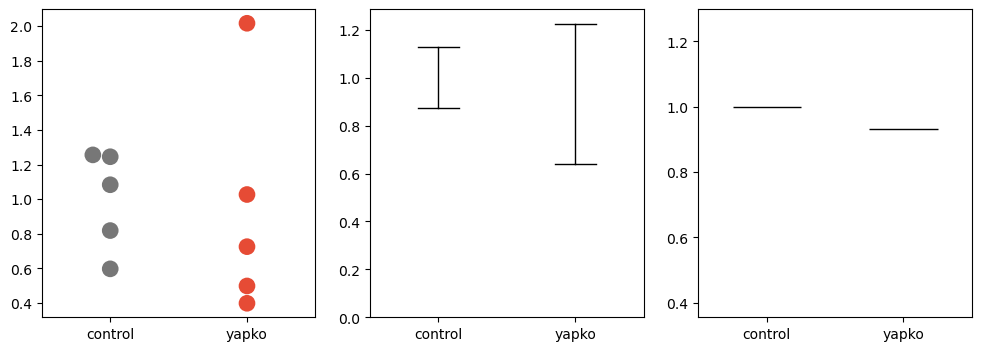

In [49]:
#We can take a look at all three plots side-by-side using plt.subplots()
#In this case, we would specify the dimensions based on how many subplots we want along each axis
fig, ax = plt.subplots(1, 3, figsize=(12,4))
#So this sets up 1 row of subplots
#and three columns of subplots
#So essentially three subplots side by side in a row
#and we can specify the figure size as well in the plt.subplots() function

#We can plot onto each subplot by specifying which axes we want to plot on

dot_colors = ['#777777', '#E64B35']

sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
    ax=ax[0],               #This plots on the first subplot by pulling out the first element of ax
)

sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
    ax=ax[1],              #This plots on the second subplot by pulling out the second element of ax
)

sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
    ax=ax[2],              #This plots on the third subplot by pulling out the third element of ax
)

<h3>Now let's overlay all our plots</h3>

<Axes: >

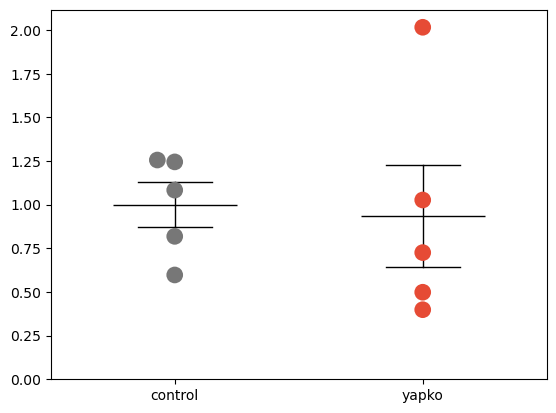

In [51]:
#We can then simply plot everything onto a single axis
#In this case, we set up fig, ax = plt.subplots() like we've done previously
fig, ax = plt.subplots()

dot_colors = ['#777777', '#E64B35']

sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
)

sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
)

sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
)

<h3>Re-order the sequence that plots are overlaid</h3>

You can see that our swarmplot is overlaid on top of our descriptive statistics, so we need to change the order in which each plot appears, so that our descriptive statistics are on top. We can do this by passing a <code>zorder</code> parameter to our swarmplot to move it under everything else.

<Axes: >

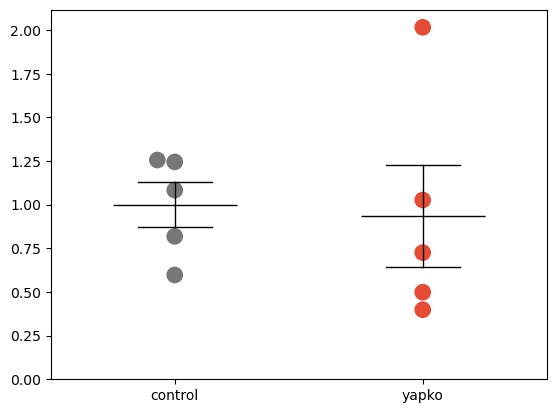

In [52]:
fig, ax = plt.subplots()

dot_colors = ['#777777', '#E64B35']

sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
    zorder=0,             #This additional argument here pushes the swarmplot to the bottom of the "stack"
)

sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
)

sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
)

<h2>Fine tune our figure</h2>

Now our plot is looking much nicer and more like a publication quality figure. However, we still need to update the labels and axis titles.

Since our plot set up is slightly different, we'll pull from slightly different attributes to define what our titles and axes labels will be. The concept is still the same as before, but the exact attribute we're calling is different.

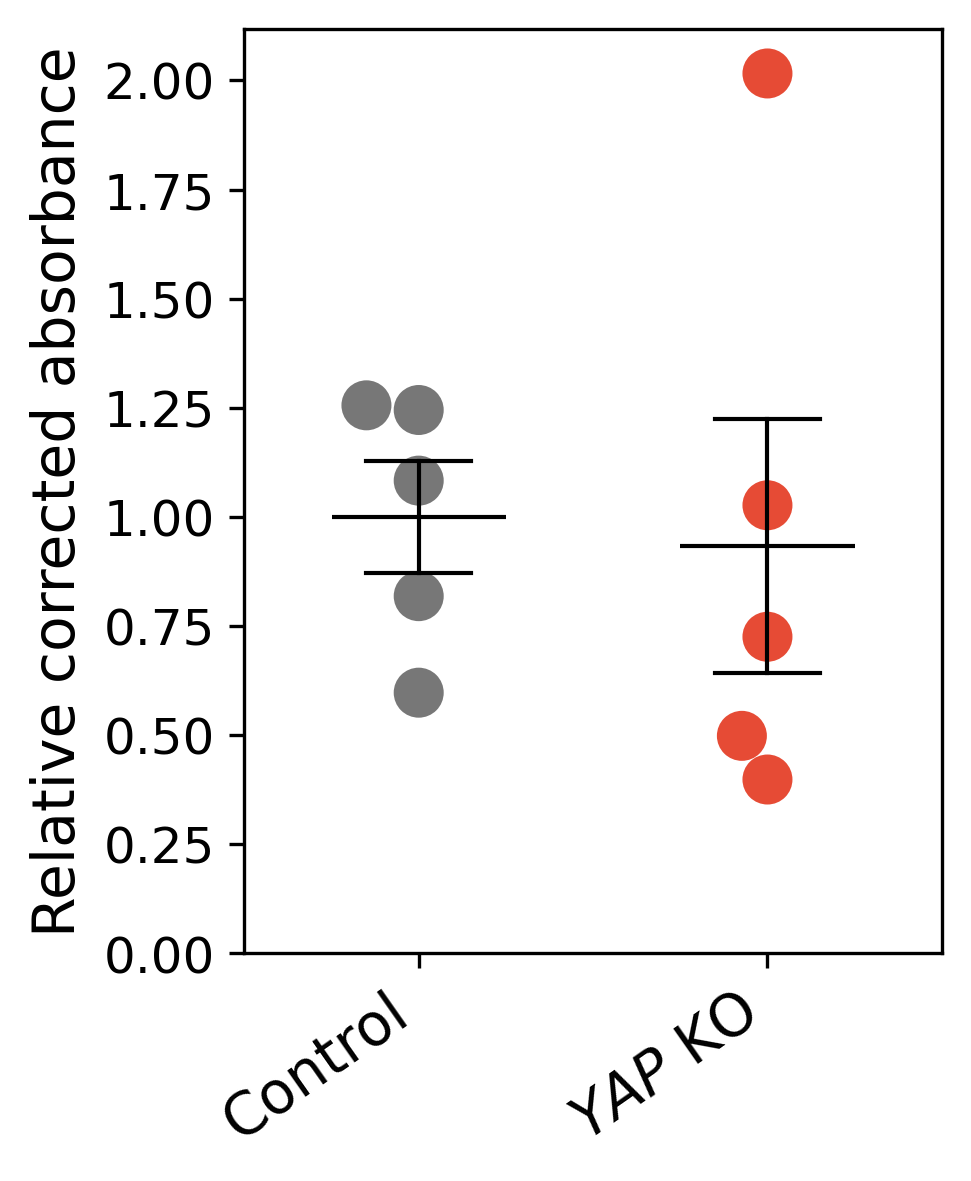

In [58]:
fig, ax = plt.subplots()

dot_colors = ['#777777', '#E64B35']

sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
    zorder=0,
)

sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
)

sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
)

#Fine tune our figures to make it pretty
ax.set_ylabel(
    'Relative corrected absorbance',
    size=14,
)

ax.set_xticks(
    [0,1],
    ['Control', '$YAP$ KO'],
)

plt.yticks(
    size=12,
)

plt.xticks(
    rotation=35,
    ha='right',
    size=14,
)

fig.set_size_inches(3, 4)

fig.set_dpi(300)

plt.show()

<h2>Despine</h2>

One of the benefits of using <code>seaborn</code> is that we can in a single line remove the spines of our plots.

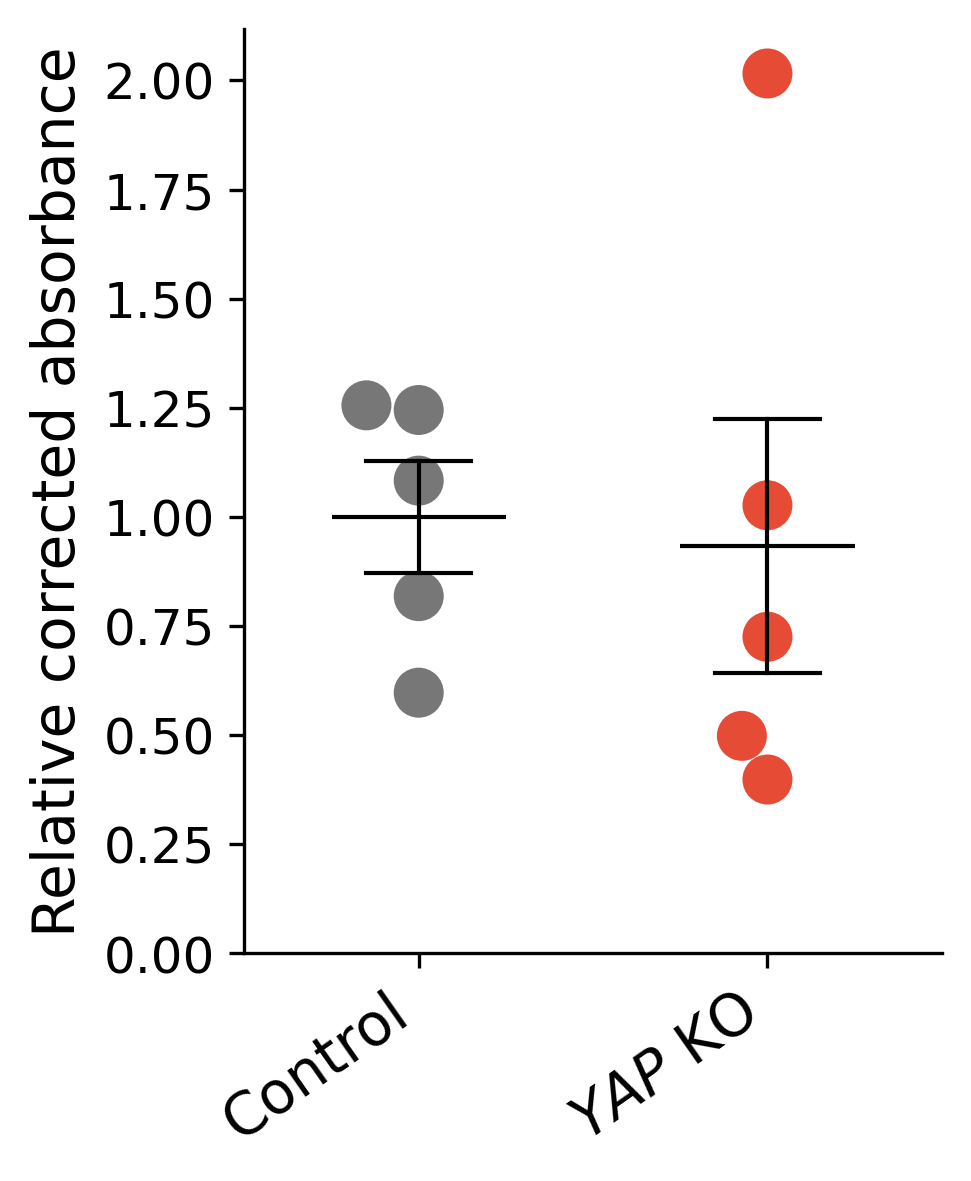

In [59]:
fig, ax = plt.subplots()

dot_colors = ['#777777', '#E64B35']

sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
    zorder=0,
)

sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
)

sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
)

#Fine tune our figures to make it pretty
ax.set_ylabel(
    'Relative corrected absorbance',
    size=14,
)

ax.set_xticks(
    [0,1],
    ['Control', '$YAP$ KO'],
)

plt.yticks(
    size=12,
)

plt.xticks(
    rotation=35,
    ha='right',
    size=14,
)

fig.set_size_inches(3, 4)

fig.set_dpi(300)

sns.despine()

plt.show()

<h2>Export your plot</h2>

Let's export our plot now that we have our nice publication quality figure.

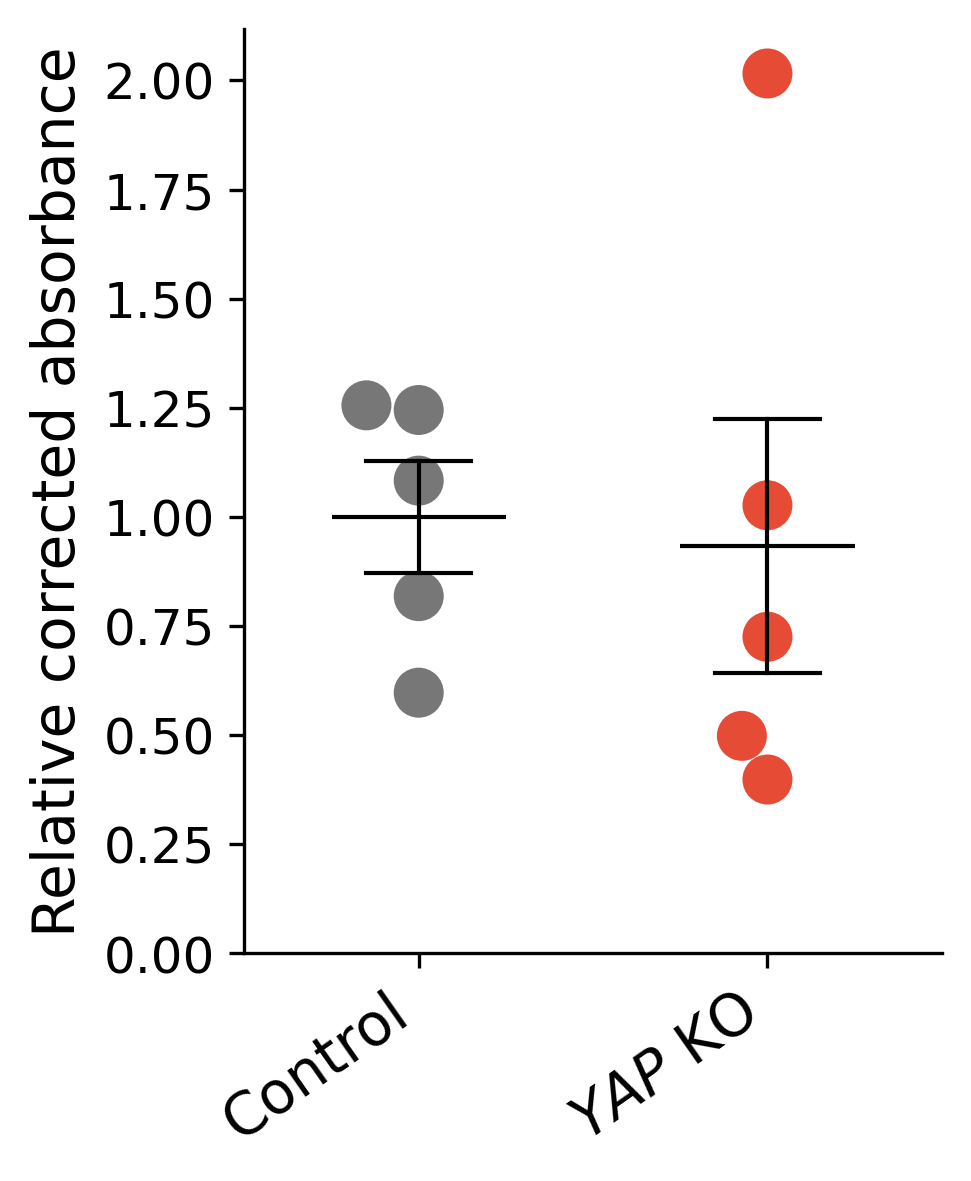

In [60]:
fig, ax = plt.subplots()

dot_colors = ['#777777', '#E64B35']

sns.swarmplot(
    data=mtt_data,
    s=12,
    palette=dot_colors,
    zorder=0,
)

sns.barplot(
    data=mtt_data,
    estimator=np.mean,
    alpha=0,
    errorbar='se',
    capsize=0.3,
    err_kws={
        'linewidth': 1,
        'color': 'black',
    },
)

sns.boxplot(
    data=mtt_data,
    showmeans=True,
    meanline=True,
    width=0.5,
    meanprops={
        'color': 'black',
        'linestyle': '-',
        'linewidth': 1,
    },
    medianprops={'visible': False},
    whiskerprops={'visible': False},
    showfliers=False,
    showbox=False,
    showcaps=False,
)

#Fine tune our figures to make it pretty
ax.set_ylabel(
    'Relative corrected absorbance',
    size=14,
)

ax.set_xticks(
    [0,1],
    ['Control', '$YAP$ KO'],
)

plt.yticks(
    size=12,
)

plt.xticks(
    rotation=35,
    ha='right',
    size=14,
)

fig.set_size_inches(3, 4)

fig.set_dpi(300)

sns.despine()

plt.show()

fig.savefig(
    'class_mtt_yap_swarplot.pdf',
    bbox_inches='tight',
)